
# Grouped BNN Selection: Failure, PIP Dilution, and Representation Warmup

This notebook is organized as a **report**, not as a diagnostic scratchpad.

The sequence is:

1. define the shallow grouped Bayesian neural network and the two grouped-selection targets;
2. describe the attention-conditioned affine variational flow in more detail;
3. use the **current metric definitions**;
4. reproduce the no-warmup comparison:
   - \(p=1,\ H=5,\ H_{\mathrm{true}}=2\): unit selection;
   - \(p=6,\ H=5,\ H_{\mathrm{true}}=2\): unit selection;
   - the same \(p=6,\ H=5\) teacher: variable selection;
5. summarize the earlier \(H=2\) versus \(H=6\) PIP-only diagnostic and the emerging \(1/H\) identity-allocation scale;
6. introduce **representation warmup with no selection**;
7. repeat the \(p=6,\ H=5\) unit- and variable-selection experiments using warmup;
8. use the **final epoch** as the posterior endpoint and drop intermediate \(R^2\)-based model selection;
9. render the final posterior-density and nonlinear function-recovery figures.

The numerical tables already established in the preceding experiments are retained as report text where available. The runnable cells use the current `bnn_train.py` and `metric.py` interfaces.


In [1]:

import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

%load_ext autoreload
%autoreload 2

import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

import Python.config as cfg
import Python.utils as ut
import Python.simfun as sim
import Python.model2 as md
import Python.metric as me
import Python.bnn_mcmc as mcmc
import Python.bnn_train as train

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seed = 123
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 220)

acceptance = md.run_grouped_acceptance_tests(device=device)
acceptance


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


{'hidden_units': 3,
 'scalar_slabs': 13,
 'unit_groups': 3,
 'group_activations': 3,
 'one_gate_per_unit': True,
 'unit_gate_applied_once': True,
 'plain_relu_gate': True,
 'relu_hidden_activation': True,
 'attention_input_output_metadata': True,
 'embedding_removed': True,
 'extra_output_projection_removed': True,
 'b2_removed': True,
 'linear_skip_default': False,
 'flow_inverse_error': 8.881784197001252e-16,
 'flow_logdet_error': 4.440892098500626e-16,
 'conditioner_independence_error': 0.0,
 'random_mask_dependency_coverage': True}


## 1. Model and grouped selection

### 1.1 Shallow ReLU network

For scalar output,

$$
f(x)
=
\beta_0
+
\sum_{j=1}^{H}
g_j\,W_{2j}\,
\operatorname{ReLU}
\left(
W_{1j}^{\top}x+b_{1j}
\right).
$$

The report uses the shallow architecture directly:

- no embedding layer;
- no additional output projection;
- no \(b_2\);
- no linear skip;
- ordinary ReLU hidden activation.

The key object is not an individual edge but a **selectable group**.

### 1.2 One latent gate for one hidden unit

For hidden unit \(j\),

$$
G_j^U
=
\left\{
W_1[j,:],\ b_1[j],\ W_2[:,j]
\right\}.
$$

The hard inclusion state is

$$
I_j
=
I(u_j>t).
$$

The same binary indicator may algebraically multiply all parameter blocks in the hard model because

$$
I_j^m=I_j.
$$

After relaxation, however,

$$
g_j^m\neq g_j.
$$

Therefore the continuous gate is **not** multiplied into the input and output blocks separately. It is applied once to the entire unit contribution:

$$
g_j
=
\operatorname{ReLU}(u_j-t),
$$

$$
c_j(x)
=
g_jW_{2j}
\operatorname{ReLU}
\left(
W_{1j}^{\top}x+b_{1j}
\right).
$$

Hence

$$
f(x)
=
\beta_0+\sum_{j=1}^{H}c_j(x).
$$

This gives exactly one selection event per hidden unit.

### 1.3 One latent gate for one original variable

For original predictor \(x_k\),

$$
G_k^F
=
W_1[:,k].
$$

Its inclusion state is

$$
I_k^F
=
I(u_k^F>t),
$$

with relaxed gate

$$
g_k^F
=
\operatorname{ReLU}(u_k^F-t).
$$

The first-layer column is therefore gated as a whole:

$$
W_1[:,k]
\longmapsto
g_k^F W_1[:,k].
$$

The two selection modes use the same principle:

$$
\boxed{
\text{one selectable object}
\Longleftrightarrow
\text{one activation latent}
\Longleftrightarrow
\text{one ReLU gate}
}
$$

The difference is only the definition of the group:

$$
G_j^U
=
\{W_1[j,:],b_1[j],W_2[:,j]\},
\qquad
G_k^F
=
W_1[:,k].
$$



## 2. Attention-conditioned affine normalizing flow

Let the full latent vector be

$$
\xi=(s,u,t)\in\mathbb R^D,
$$

and start from a trainable diagonal Gaussian base distribution

$$
z_0
\sim
q_0(z_0)
=
\mathcal N
\left(
\mu_0,\operatorname{diag}(\sigma_0^2)
\right).
$$

A sequence of invertible transformations gives

$$
z_K
=
T_K\circ\cdots\circ T_1(z_0)
=
\xi.
$$

The induced variational log density is

$$
\log q_K(\xi)
=
\log q_0(z_0)
-
\sum_{k=1}^{K}
\log
\left|
\det
\frac{\partial T_k}{\partial z_{k-1}}
\right|.
$$

### 2.1 Masked affine coupling

For one coupling layer, split coordinates into a fixed set \(A\) and a transformed set \(B\):

$$
\xi=(\xi_A,\xi_B).
$$

The triangular affine map is

$$
\xi_A'
=
\xi_A,
$$

$$
\xi_B'
=
\xi_B\odot
\exp\{\lambda_B(\xi_A)\}
+
\mu_B(\xi_A).
$$

The inverse is analytic:

$$
\xi_B
=
\left(
\xi_B'-\mu_B(\xi_A)
\right)
\odot
\exp\{-\lambda_B(\xi_A)\}.
$$

Because only the \(B\) block is transformed, the Jacobian is triangular and

$$
\log
\left|
\det J
\right|
=
\sum_{i\in B}\lambda_i.
$$

The scale is bounded in the implementation. If the conditioner produces raw scale
\(\widetilde\lambda_i\), then

$$
\lambda_i
=
c\,
\tanh
\left(
\frac{\widetilde\lambda_i}{c}
\right),
$$

where \(c\) is `scale_clip`.

### 2.2 Attention conditioner

The distinction from an ordinary MLP affine coupling is the map

$$
\xi_A
\longmapsto
\{\lambda_B,\mu_B\}.
$$

Each fixed latent coordinate is represented as a token. In generic notation,

$$
h_i
=
e_{\mathrm{value}}(\xi_i)
+
e_{\mathrm{coordinate}}(i)
+
e_{\mathrm{type}}(i)
+
e_{\mathrm{structure}}(i),
$$

where the structural metadata identify the role of a coordinate in the grouped latent representation. The metadata are used by the flow conditioner only; they do **not** create extra selection gates.

For attention head \(r\),

$$
Q_r = H_AW_r^Q,
\qquad
K_r = H_AW_r^K,
\qquad
V_r = H_AW_r^V,
$$

and the self-attention weights are

$$
A_r
=
\operatorname{softmax}
\left(
\frac{Q_rK_r^\top}{\sqrt{d_r}}
\right).
$$

The fixed-side context is

$$
C_r=A_rV_r.
$$

After multi-head concatenation and normalization, the transformed coordinates are represented by target queries. Cross-attention then lets each target coordinate read the fixed-side context:

$$
Q_r^{(B)}
=
H_B^{\mathrm{query}}W_r^Q,
$$

$$
C_r^{(B)}
=
\operatorname{softmax}
\left(
\frac{
Q_r^{(B)}
(K_r^{(A)})^\top
}{
\sqrt{d_r}
}
\right)
V_r^{(A)}.
$$

A final readout returns two values per transformed coordinate,

$$
(\widetilde\lambda_i,\mu_i),
\qquad i\in B,
$$

followed by the bounded-scale transformation above.

The important design point is:

$$
\boxed{
\text{the affine coupling remains exactly invertible, while attention learns which fixed latent coordinates are useful for each transformed coordinate.}
}
$$

### 2.3 Complementary masks

The masks are fixed when the flow is constructed. Across successive coupling layers, complementary balanced partitions allow both halves of the latent vector to be transformed.

Thus the posterior family combines:

1. a simple Gaussian base;
2. exact change-of-variable density evaluation;
3. triangular affine maps;
4. attention-based conditioning across latent coordinates.

The resulting ELBO is

$$
\mathcal L
=
E_{q_\psi(\xi)}
\left[
\log p(y\mid \xi)
+
\log p(\xi)
-
\log q_\psi(\xi)
\right].
$$



## 3. Current evaluation metrics

The current metric implementation separates **selection truth**, **posterior agreement**, and **function recovery**.

### 3.1 PIP error against simulation truth

Let

$$
\widehat\pi_g
=
P_q(I_g=1\mid y)
$$

and let \(z_g^\star\in\{0,1\}\) be the known simulation truth. Then

$$
\operatorname{RMSE}_{\mathrm{PIP,true}}
=
\sqrt{
\frac{1}{G}
\sum_{g=1}^{G}
\left(
\widehat\pi_g-z_g^\star
\right)^2
}.
$$

This is the direct selection-recovery metric in simulation.

### 3.2 PIP error against MCMC

$$
\operatorname{RMSE}_{\mathrm{PIP,MCMC}}
=
\sqrt{
\frac{1}{G}
\sum_{g=1}^{G}
\left(
\widehat\pi_g^{\,\mathrm{RaT}}
-
\widehat\pi_g^{\,\mathrm{MCMC}}
\right)^2
}.
$$

This measures posterior inclusion **agreement with the reference**, not truth-selection error.

### 3.3 Conditional active-slab SKL

For each truth-active group \(g\), define the continuous slab-strength variable \(S_g\). The comparison is conditional on the group being active:

$$
q_g^+(s)
=
q(S_g=s\mid I_g=1,y),
$$

$$
p_g^+(s)
=
p_{\mathrm{MCMC}}(S_g=s\mid I_g=1,y).
$$

The symmetric KL is

$$
D_{\mathrm{SKL},g}
=
\frac12
D_{\mathrm{KL}}(q_g^+\|p_g^+)
+
\frac12
D_{\mathrm{KL}}(p_g^+\|q_g^+).
$$

`true_active_skl` is the median across truth-active targets with enough active draws.

### 3.4 Inactive zero-mass JS

For truth-zero groups, the zero/inclusion discrepancy is summarized by the Jensen--Shannon divergence between the Bernoulli inclusion distributions implied by the RaT and MCMC PIPs.

This is a reference-disagreement metric. A larger value does not automatically mean worse truth selection if MCMC itself assigns appreciable inclusion mass to redundant groups.

### 3.5 Two-target joint posterior density

When there are exactly two truth-active targets, the plotted density uses only draws in which **both targets are active in the same posterior draw**:

$$
p(S_1,S_2\mid I_1=1,I_2=1,y).
$$

For unit selection, the targets are permutation-invariant ranked units. For feature selection, they are the two original truth-active predictors.

If too few joint-active RaT draws exist, the density is intentionally not estimated.

### 3.6 Function recovery

For the noiseless teacher signal \(f^\star\) and posterior-mean function \(\widehat f\),

$$
R^2
=
1-
\frac{
\sum_i
\left(
f^\star(x_i)-\widehat f(x_i)
\right)^2
}{
\sum_i
\left(
f^\star(x_i)-\overline{f^\star}
\right)^2
}.
$$

The report treats \(R^2\) primarily as a **functional sanity check**, while PIP truth error and active-slab SKL address different parts of the inferential problem.

`PIP sum` is not used as a report metric; it was useful only during diagnosis.


In [4]:

# ------------------------------------------------------------
# Shared settings and reusable helpers
# ------------------------------------------------------------

run_cfg = dict(
    mcmc_N=5000,
    mcmc_burnin=100,
    epochs=2500,
    lr=3e-4,
    R_train=100,
    R_eval=300,
    R_final=1000,
    eval_every=250,
    init_loc_jitter=0.05,
)

def arch(p, H):
    return dict(
        input_dim=p,
        H=H,
        out_dim=1,
        gate_power=1.0,
        gate_tau=None,
        repu_power=None,
        linear_skip=False,
    )


def prepare_reference(
    data,
    *,
    selection_mode,
    H,
    case_seed,
):
    """
    Build one train/val/test split and one exactly matched reference posterior.
    """
    X, y, feature_true, unit_true, signal, info = data

    split_cfg = cfg.SplitConfig(
        train_frac=0.60,
        val_frac=0.20,
        test_frac=0.20,
        seed=case_seed,
    )

    indices = ut.make_split(
        X.shape[0],
        split_cfg,
    )

    splits = ut.split_data(
        X,
        y,
        indices,
        mode="tensor",
    )

    signal_splits = ut.split_data(
        X,
        signal,
        indices,
        mode="tensor",
    )

    architecture = arch(
        p=X.shape[1],
        H=H,
    )

    ref_model = md.GroupedBNNVI(
        X=splits["X_train"],
        y=splits["y_train"],
        selection_mode=selection_mode,
        family=info["family"],
        sigma2=info["sigma2"],
        init_sd=0.5,
        K_flow=0,
        flow_type="meanfield",
        **architecture,
    ).to(device)

    ref = mcmc.run_bnn_mcmc(
        model=ref_model,
        N=run_cfg["mcmc_N"],
        S_max=100,
        burnin=run_cfg["mcmc_burnin"],
        thin=1,
        seed=case_seed,
        print_every=250,
    )

    ref_xi = torch.as_tensor(
        ref["xi_draws"],
        device=device,
        dtype=X.dtype,
    )

    return {
        "data": data,
        "info": info,
        "splits": splits,
        "signal_splits": signal_splits,
        "architecture": architecture,
        "mcmc_model": ref_model,
        "mcmc_xi": ref_xi,
        "mcmc_ref": ref,
        "seed": case_seed,
        "selection_mode": selection_mode,
    }


def train_from_reference(
    ref_case,
    *,
    selection_warmup_epochs,
):
    X, y, feature_true, unit_true, signal, info = ref_case["data"]
    splits = ref_case["splits"]
    signal_splits = ref_case["signal_splits"]

    out = train.train_grouped_bnn(
        X_train=splits["X_train"],
        y_train=splits["y_train"],
        X_eval=splits["X_val"],
        signal_eval=signal_splits["y_val"],
        X_final=splits["X_test"],
        signal_final=signal_splits["y_test"],

        mcmc_decoder=ref_case["mcmc_model"].decoder,
        mcmc_xi=ref_case["mcmc_xi"],
        truth=info,

        selection_mode=ref_case["selection_mode"],
        family=info["family"],
        sigma2=info["sigma2"],
        init_sd=0.5,

        K_flow=8,
        flow_type="attention_affine",
        flow_hidden_units=64,
        flow_hidden_layers=2,
        scale_clip=1.5,
        flow_token_dim=32,
        flow_num_heads=4,
        flow_mask_seed=ref_case["seed"],

        epochs=run_cfg["epochs"],
        lr=run_cfg["lr"],
        R_train=run_cfg["R_train"],
        R_eval=run_cfg["R_eval"],
        R_final=run_cfg["R_final"],
        eval_every=run_cfg["eval_every"],

        selection_warmup_epochs=selection_warmup_epochs,
        init_loc_jitter=run_cfg["init_loc_jitter"],

        endpoint="last",
        checkpoint_metric=None,

        seed=ref_case["seed"],
        **ref_case["architecture"],
    )

    return {
        **ref_case,
        "out": out,
        "selection_warmup_epochs": int(selection_warmup_epochs),
    }


def compact_summary(case, label):
    s = case["out"]["final"]["summary"]

    row = {
        "case": label,
        "mode": case["selection_mode"],
        "warmup": case["selection_warmup_epochs"],
        "PIP_RMSE_truth": s["pip_rmse_truth"],
        "PIP_RMSE_MCMC": s["pip_rmse_mcmc"],
        "active_SKL": s["true_active_skl"],
        "zero_JS": s["zero_js"],
        "RaT_R2": s["rat_signal_r2"],
        "MCMC_R2": s["mcmc_signal_r2"],
        "RaT_MSE": s["rat_mse"],
        "MCMC_MSE": s["mcmc_mse"],
        "ELBO": s["elbo"],
    }

    return pd.DataFrame([row])


def show_recovery(case):
    display(
        case["out"]["final"]["recovery_by_target"].round(4)
    )

    if not case["out"]["final"]["unit_metrics"].empty:
        display(
            case["out"]["final"]["unit_metrics"].round(4)
        )



# Part I — No-warmup experiments

The first three experiments deliberately use

```python
selection_warmup_epochs = 0
```

so that grouped selection is active from the beginning.

The purpose is to reproduce the central contrast:

$$
\boxed{
\text{variable selection succeeds}
\qquad\text{while}\qquad
\text{multivariable unit selection fails}.
}
$$


## Experiment A — one variable, five candidate units, two true units

Configuration:

$$
n=160,\qquad p=1,\qquad H=5,\qquad H_{\mathrm{true}}=2.
$$

There is only one input direction, so this is the low-dimensional unit-selection sanity check.

In the **current run**, the final-epoch result is:

| quantity | current value |
|---|---:|
| PIP RMSE truth | \(0.3157\) |
| PIP RMSE MCMC | \(0.3229\) |
| active SKL | \(0.0980\) |
| zero JS | \(0.1275\) |
| RaT test \(R^2\) | \(0.9654\) |
| MCMC test \(R^2\) | \(0.9464\) |
| RaT test MSE | \(0.1042\) |
| MCMC test MSE | \(0.1615\) |

The two truth-active ranked units are recovered with

$$
PIP_{(1)}=PIP_{(2)}=1.
$$

Their conditional slab-strength SKLs are

$$
0.0855,\qquad 0.1104,
$$

so the reported median active SKL is

$$
D_{\mathrm{SKL},A}=0.0980.
$$

The three truth-zero ranked units retain some posterior occupancy:

$$
(0.650,\ 0.270,\ 0.054).
$$

Thus the one-dimensional problem successfully recovers the two active units and the nonlinear function, but the posterior is not perfectly sparse over redundant unit slots.

For the two truth-active ranked units, all \(1000\) RaT final draws and all \(4900\) MCMC reference draws are jointly active. The conditional two-dimensional joint SKL is

$$
D_{\mathrm{SKL,joint}}=0.2085.
$$

In [5]:

data_A = sim.simfun_grouped_bnn(
    n=160,
    p=1,
    active_features=(0,),
    n_true_units=2,
    fit_units=5,
    repu_power=None,
    sigma2=1.0,
    seed=seed,
    device=device,
)

ref_A = prepare_reference(
    data_A,
    selection_mode="unit_group",
    H=5,
    case_seed=seed,
)

case_A_nowarm = train_from_reference(
    ref_A,
    selection_warmup_epochs=0,
)

display(
    compact_summary(
        case_A_nowarm,
        "A: p=1, H=5, unit, no warmup",
    ).round(4)
)

show_recovery(case_A_nowarm)


mcmc_iter=00001 loglik=-532.642
mcmc_iter=00250 loglik=-138.618
mcmc_iter=00500 loglik=-141.988
mcmc_iter=00750 loglik=-137.925
mcmc_iter=01000 loglik=-138.873
mcmc_iter=01250 loglik=-139.106
mcmc_iter=01500 loglik=-138.283
mcmc_iter=01750 loglik=-138.357
mcmc_iter=02000 loglik=-139.522
mcmc_iter=02250 loglik=-142.042
mcmc_iter=02500 loglik=-138.667
mcmc_iter=02750 loglik=-142.118
mcmc_iter=03000 loglik=-140.801
mcmc_iter=03250 loglik=-140.206
mcmc_iter=03500 loglik=-142.533
mcmc_iter=03750 loglik=-138.323
mcmc_iter=04000 loglik=-138.535
mcmc_iter=04250 loglik=-138.483
mcmc_iter=04500 loglik=-139.222
mcmc_iter=04750 loglik=-142.335
mcmc_iter=05000 loglik=-139.954
epoch=0001 phase=select valR2=-6.3310 pipTruth=0.3091 activeSKL=7.3334
epoch=0250 phase=select valR2=0.9572 pipTruth=0.7208 activeSKL=4.8811
epoch=0500 phase=select valR2=0.9605 pipTruth=0.0792 activeSKL=1.3622
epoch=0750 phase=select valR2=0.9653 pipTruth=0.1488 activeSKL=0.5850
epoch=1000 phase=select valR2=0.9696 pipTruth=0

,case,mode,warmup,PIP_RMSE_truth,PIP_RMSE_MCMC,active_SKL,zero_JS,RaT_R2,MCMC_R2,RaT_MSE,MCMC_MSE,ELBO
0,"A: p=1, H=5, unit, no warmup",unit_group,0,0.3157,0.3229,0.098,0.1275,0.9654,0.9464,0.1042,0.1615,-158.6054


,target_type,target,label,truth_active,truth_pip,rat_pip,mcmc_pip,pip_error_truth,pip_error,conditional_slab_skl,zero_mass_js,n_rat_active_draws,n_mcmc_active_draws
0,unit_rank,0,unit_rank_1,True,1.0,1.000,1.0000,0.000,0.0000,0.0855,NaN,1000,4900
1,unit_rank,1,unit_rank_2,True,1.0,1.000,1.0000,0.000,0.0000,0.1104,NaN,1000,4900
2,unit_rank,2,unit_rank_3,False,0.0,0.650,0.9422,0.650,-0.2922,NaN,0.0716,650,4617
3,unit_rank,3,unit_rank_4,False,0.0,0.270,0.7771,0.270,-0.5071,NaN,0.1352,270,3808
4,unit_rank,4,unit_rank_5,False,0.0,0.054,0.4767,0.054,-0.4227,NaN,0.1275,54,2336


,method,epoch,block,unit,group_id,posterior_rank,unit_pip,gate_mean,margin_mean,margin_sd,input_slab_norm_mean,output_slab_norm_mean,slab_strength_mean,effective_strength_mean
0,RaT,2500,0,0,0,1,1.0000,1.3000,1.3000,0.4940,1.5477,1.1984,1.7698,2.0292
1,RaT,2500,0,3,3,2,1.0000,1.2516,1.2516,0.4870,1.4534,1.0901,1.5350,1.6739
2,RaT,2500,0,2,2,3,0.3460,0.1892,-0.3726,0.8647,1.1716,0.6008,0.7123,0.0737
3,RaT,2500,0,4,4,4,0.3280,0.1739,-0.3819,0.8307,1.2128,0.6625,0.8291,0.0582
4,RaT,2500,0,1,1,5,0.3000,0.1542,-0.3933,0.7600,1.1685,0.7050,0.8327,0.0618
5,MCMC,None,0,2,2,1,0.8961,1.2928,1.2215,1.0216,1.4333,0.9138,1.2076,1.3615
6,MCMC,None,0,3,3,2,0.8616,1.2876,1.1893,1.0958,1.4085,0.8593,1.0980,1.2781
7,MCMC,None,0,0,0,3,0.8478,1.2899,1.1798,1.1259,1.1863,0.9053,1.0469,1.2218
8,MCMC,None,0,1,1,4,0.8167,1.1196,0.9910,1.1399,1.2625,0.8525,1.0507,1.0061
9,MCMC,None,0,4,4,5,0.7739,1.1448,0.9785,1.2791,1.1934,0.7835,0.9298,0.8648


## Experiment B — six variables, five candidate units, two true units

The multivariable teacher is

$$
n=240,\qquad
p=6,\qquad
H=5,
$$

with two active original variables,

$$
x_0,\qquad x_3,
$$

and two true ReLU units.

The unit-selection target remains

$$
G_j^U
=
\{W_1[j,:],b_1[j],W_2[:,j]\}.
$$

The crucial change from Experiment A is that each candidate unit now contains a six-dimensional incoming vector.

With **no warmup**, the current run fails sharply:

| quantity | current value |
|---|---:|
| PIP RMSE truth | \(0.6134\) |
| PIP RMSE MCMC | \(0.7204\) |
| active SKL | \(1.0116\) |
| zero JS | \(0.1442\) |
| RaT test \(R^2\) | \(-0.0034\) |
| MCMC test \(R^2\) | \(0.9478\) |
| RaT test MSE | \(2.4873\) |
| MCMC test MSE | \(0.1293\) |

The truth-active ranked-unit PIPs are only

$$
PIP_{(1)}=0.057,
\qquad
PIP_{(2)}=0.004,
$$

while the remaining ranked PIPs are zero in the final recovery table.

Only the first truth-active rank has enough RaT active draws for a conditional one-dimensional slab comparison, giving

$$
D_{\mathrm{SKL}}=1.0116.
$$

The second truth-active rank has only \(4\) active RaT draws and therefore does not meet the minimum-draw requirement for a stable conditional slab KDE.

The joint-active probability is

$$
P_q(I_{(1)}=1,I_{(2)}=1)=0.004,
$$

corresponding to only \(4\) of the \(1000\) final RaT draws. The MCMC reference has both truth-active ranks active in all \(4900\) retained draws.

Therefore the two-dimensional true-active RaT density is **not plotted** in this experiment because the joint-active sample is insufficient.

The raw fitted-unit summary also shows the mechanism clearly: all five fitted units have strongly negative mean margins (approximately \(-1.54\) to \(-1.63\)) and extremely small mean gates, even though their slab norms remain non-negligible. The failure is therefore a selection/optimization failure rather than disappearance of the continuous slab parameters.

In [6]:

data_p6_h5 = sim.simfun_grouped_bnn(
    n=240,
    p=6,
    active_features=(0, 3),
    n_true_units=2,
    fit_units=5,
    repu_power=None,
    sigma2=1.0,
    seed=seed + 1,
    device=device,
)

print("feature truth:")
print(data_p6_h5[2])

print("\nunit truth:")
print(data_p6_h5[3])

print("\nteacher units:")
display(
    pd.DataFrame(
        data_p6_h5[-1]["teacher_units"]
    ).round(4)
)


feature truth:
tensor([1., 0., 0., 1., 0., 0.])

unit truth:
tensor([1., 1., 0., 0., 0.])

teacher units:


,teacher_unit,feature,slope,breakpoint,bias,amplitude
0,0,0,1.2361,0.0456,0.0564,1.0813
1,1,3,-1.0950,0.0457,-0.0501,1.1891


In [7]:

ref_B_unit = prepare_reference(
    data_p6_h5,
    selection_mode="unit_group",
    H=5,
    case_seed=seed + 1,
)

case_B_nowarm = train_from_reference(
    ref_B_unit,
    selection_warmup_epochs=0,
)

display(
    compact_summary(
        case_B_nowarm,
        "B: p=6, H=5, unit, no warmup",
    ).round(4)
)

show_recovery(case_B_nowarm)


mcmc_iter=00001 loglik=-372.578
mcmc_iter=00250 loglik=-200.526
mcmc_iter=00500 loglik=-209.079
mcmc_iter=00750 loglik=-202.397
mcmc_iter=01000 loglik=-201.221
mcmc_iter=01250 loglik=-199.701
mcmc_iter=01500 loglik=-198.569
mcmc_iter=01750 loglik=-204.144
mcmc_iter=02000 loglik=-206.965
mcmc_iter=02250 loglik=-200.413
mcmc_iter=02500 loglik=-200.332
mcmc_iter=02750 loglik=-204.987
mcmc_iter=03000 loglik=-208.320
mcmc_iter=03250 loglik=-202.380
mcmc_iter=03500 loglik=-205.193
mcmc_iter=03750 loglik=-206.771
mcmc_iter=04000 loglik=-204.014
mcmc_iter=04250 loglik=-199.976
mcmc_iter=04500 loglik=-197.699
mcmc_iter=04750 loglik=-198.602
mcmc_iter=05000 loglik=-210.277
epoch=0001 phase=select valR2=-0.9890 pipTruth=0.3027 activeSKL=3.8680
epoch=0250 phase=select valR2=-0.0059 pipTruth=0.6220 activeSKL=nan
epoch=0500 phase=select valR2=-0.0078 pipTruth=0.6219 activeSKL=nan
epoch=0750 phase=select valR2=-0.0074 pipTruth=0.6272 activeSKL=nan
epoch=1000 phase=select valR2=-0.0107 pipTruth=0.6262

,case,mode,warmup,PIP_RMSE_truth,PIP_RMSE_MCMC,active_SKL,zero_JS,RaT_R2,MCMC_R2,RaT_MSE,MCMC_MSE,ELBO
0,"B: p=6, H=5, unit, no warmup",unit_group,0,0.6134,0.7204,1.0116,0.1442,-0.0034,0.9478,2.4873,0.1293,-364.8108


,target_type,target,label,truth_active,truth_pip,rat_pip,mcmc_pip,pip_error_truth,pip_error,conditional_slab_skl,zero_mass_js,n_rat_active_draws,n_mcmc_active_draws
0,unit_rank,0,unit_rank_1,True,1.0,0.057,1.0000,-0.943,-0.9430,1.0116,NaN,57,4900
1,unit_rank,1,unit_rank_2,True,1.0,0.004,1.0000,-0.996,-0.9960,NaN,NaN,4,4900
2,unit_rank,2,unit_rank_3,False,0.0,0.000,0.7604,0.000,-0.7604,NaN,0.3889,0,3726
3,unit_rank,3,unit_rank_4,False,0.0,0.000,0.3590,0.000,-0.3590,NaN,0.1442,0,1759
4,unit_rank,4,unit_rank_5,False,0.0,0.000,0.0786,0.000,-0.0786,NaN,0.0280,0,385


,method,epoch,block,unit,group_id,posterior_rank,unit_pip,gate_mean,margin_mean,margin_sd,input_slab_norm_mean,output_slab_norm_mean,slab_strength_mean,effective_strength_mean
0,RaT,2500,0,1,1,1,0.0270,0.0080,-1.5582,0.9187,2.5783,0.7261,1.8725,0.0051
1,RaT,2500,0,3,3,2,0.0180,0.0021,-1.6154,0.9269,2.5562,0.7921,2.0363,0.0029
2,RaT,2500,0,4,4,3,0.0070,0.0008,-1.5615,0.9109,2.5855,0.8300,2.1232,0.0031
3,RaT,2500,0,2,2,4,0.0060,0.0007,-1.5446,0.8825,2.6217,0.8251,2.1811,0.0023
4,RaT,2500,0,0,0,5,0.0030,0.0004,-1.6308,0.8287,2.5022,0.8035,1.9918,0.0002
5,MCMC,None,0,4,4,1,0.8004,0.7145,0.5978,0.8097,2.4466,0.8027,1.9122,0.9956
6,MCMC,None,0,1,1,2,0.6343,0.5079,0.2777,0.8731,2.5673,0.6830,1.7472,0.6306
7,MCMC,None,0,3,3,3,0.6314,0.4811,0.2384,0.8652,2.5903,0.6711,1.7229,0.5563
8,MCMC,None,0,2,2,4,0.5878,0.4479,0.1809,0.8829,2.5110,0.7092,1.7514,0.4984
9,MCMC,None,0,0,0,5,0.5441,0.4425,0.1395,0.9127,2.5005,0.6769,1.6867,0.4950


## Experiment C — the same six-variable teacher, variable selection

Experiment C uses exactly the same observations and the same \(H=5\) fitted network as Experiment B.

Only the selectable object changes:

$$
G_k^F=W_1[:,k].
$$

The truth is

$$
(1,0,0,1,0,0).
$$

In the **current no-warmup run**, variable selection remains accurate:

| quantity | current value |
|---|---:|
| PIP RMSE truth | \(0.0197\) |
| PIP RMSE MCMC | \(0.1625\) |
| active SKL | \(0.0752\) |
| zero JS | \(0.0420\) |
| RaT test \(R^2\) | \(0.9693\) |
| MCMC test \(R^2\) | \(0.9829\) |
| RaT test MSE | \(0.0760\) |
| MCMC test MSE | \(0.0425\) |

The truth-active feature PIPs are

$$
PIP(x_0)=PIP(x_3)=1.
$$

The four inactive feature PIPs are

$$
PIP(x_1)=0.020,\qquad
PIP(x_2)=0.019,
$$

$$
PIP(x_4)=0.033,\qquad
PIP(x_5)=0.022.
$$

The two truth-active conditional slab-strength SKLs are

$$
0.0779,\qquad 0.0725,
$$

with median

$$
D_{\mathrm{SKL},A}=0.0752.
$$

Both truth-active variables are jointly active in every final RaT draw and every retained MCMC draw. The conditional joint SKL is

$$
D_{\mathrm{SKL,joint}}=0.1701.
$$

This contrast is the central baseline result:

$$
\boxed{
\text{same nonlinear teacher}
+
\text{same attention-affine flow}
+
\text{same ReLU relaxation}
}
$$

but

$$
\boxed{
\text{feature grouping succeeds, whereas multivariable hidden-unit grouping fails without training control.}
}
$$

In [8]:

ref_C_feature = prepare_reference(
    data_p6_h5,
    selection_mode="feature_group",
    H=5,
    case_seed=seed + 1,
)

case_C_nowarm = train_from_reference(
    ref_C_feature,
    selection_warmup_epochs=0,
)

display(
    compact_summary(
        case_C_nowarm,
        "C: p=6, H=5, feature, no warmup",
    ).round(4)
)

show_recovery(case_C_nowarm)


mcmc_iter=00001 loglik=-359.121
mcmc_iter=00250 loglik=-201.502
mcmc_iter=00500 loglik=-204.058
mcmc_iter=00750 loglik=-211.355
mcmc_iter=01000 loglik=-206.962
mcmc_iter=01250 loglik=-205.309
mcmc_iter=01500 loglik=-206.546
mcmc_iter=01750 loglik=-208.046
mcmc_iter=02000 loglik=-205.682
mcmc_iter=02250 loglik=-205.605
mcmc_iter=02500 loglik=-207.189
mcmc_iter=02750 loglik=-205.946
mcmc_iter=03000 loglik=-206.285
mcmc_iter=03250 loglik=-202.163
mcmc_iter=03500 loglik=-201.532
mcmc_iter=03750 loglik=-204.620
mcmc_iter=04000 loglik=-199.907
mcmc_iter=04250 loglik=-208.807
mcmc_iter=04500 loglik=-200.732
mcmc_iter=04750 loglik=-203.731
mcmc_iter=05000 loglik=-201.761
epoch=0001 phase=select valR2=-1.1306 pipTruth=0.5076 activeSKL=5.0435
epoch=0250 phase=select valR2=0.9893 pipTruth=0.0577 activeSKL=1.7906
epoch=0500 phase=select valR2=0.9858 pipTruth=0.0284 activeSKL=0.3336
epoch=0750 phase=select valR2=0.9834 pipTruth=0.0361 activeSKL=0.3236
epoch=1000 phase=select valR2=0.9804 pipTruth=0

,case,mode,warmup,PIP_RMSE_truth,PIP_RMSE_MCMC,active_SKL,zero_JS,RaT_R2,MCMC_R2,RaT_MSE,MCMC_MSE,ELBO
0,"C: p=6, H=5, feature, no warmup",feature_group,0,0.0197,0.1625,0.0752,0.042,0.9693,0.9829,0.076,0.0425,-238.8103


,target_type,target,label,truth_active,truth_pip,rat_pip,mcmc_pip,pip_error_truth,pip_error,conditional_slab_skl,zero_mass_js,n_rat_active_draws,n_mcmc_active_draws
0,feature,0,feature_0,True,1.0,1.000,1.0000,0.000,0.0000,0.0779,NaN,1000,4900
1,feature,1,feature_1,False,0.0,0.020,0.1392,0.020,-0.1192,NaN,0.0270,20,682
2,feature,2,feature_2,False,0.0,0.019,0.1143,0.019,-0.0953,NaN,0.0201,19,560
3,feature,3,feature_3,True,1.0,1.000,1.0000,0.000,0.0000,0.0725,NaN,1000,4900
4,feature,4,feature_4,False,0.0,0.033,0.3347,0.033,-0.3017,NaN,0.0859,33,1640
5,feature,5,feature_5,False,0.0,0.022,0.2320,0.022,-0.2100,NaN,0.0570,22,1137


In [9]:

baseline_report = pd.concat(
    [
        compact_summary(
            case_A_nowarm,
            "A: p=1 H=5 unit",
        ),
        compact_summary(
            case_B_nowarm,
            "B: p=6 H=5 unit",
        ),
        compact_summary(
            case_C_nowarm,
            "C: p=6 H=5 feature",
        ),
    ],
    ignore_index=True,
)

display(
    baseline_report.round(4)
)


,case,mode,warmup,PIP_RMSE_truth,PIP_RMSE_MCMC,active_SKL,zero_JS,RaT_R2,MCMC_R2,RaT_MSE,MCMC_MSE,ELBO
0,A: p=1 H=5 unit,unit_group,0,0.3157,0.3229,0.0980,0.1275,0.9654,0.9464,0.1042,0.1615,-158.6054
1,B: p=6 H=5 unit,unit_group,0,0.6134,0.7204,1.0116,0.1442,-0.0034,0.9478,2.4873,0.1293,-364.8108
2,C: p=6 H=5 feature,feature_group,0,0.0197,0.1625,0.0752,0.0420,0.9693,0.9829,0.0760,0.0425,-238.8103



### Baseline interpretation

The three-experiment design separates two questions.

**First**, the unit parameterization itself is not intrinsically unusable: with one predictor, two truth-active nonlinear components can be recovered.

**Second**, the failure is not a generic failure of the attention-affine posterior or the ReLU gate: on the same \(p=6\) nonlinear teacher, original-variable selection remains accurate.

The difficulty appears when hidden-unit selection and multivariable representation learning are required to occur simultaneously from the beginning of optimization.



# Part II — PIP-only unit-allocation diagnostic

The next diagnostic deliberately ignores SKL, JS, and \(R^2\) and looks only at PIP behavior.

The earlier \(p=6\) unit experiments compared:

- \(H=2\), with two true units and no redundant candidates;
- \(H=6\), with two true units and four redundant candidates.

At the ranked-support level, the final no-warmup behavior was:

| candidate units | ranked RaT PIPs |
|---:|---|
| \(H=2\) | approximately \((1.000,\ 0.055)\) |
| \(H=6\) | approximately \((0.035,\ 0,\ 0,\ 0,\ 0,\ 0)\) |

This table shows the **support failure** itself.

A separate teacher-identity matching diagnostic in the \(H=2\) run showed probabilities fluctuating around

$$
(0.57,\ 0.47),
$$

which is close to the exchangeable per-slot scale

$$
\frac{1}{H}
=
\frac12.
$$

This motivates the more structural interpretation:

$$
\boxed{
\text{when hidden-unit identities are exchangeable, posterior identity mass is diluted across candidate slots, with a natural per-slot scale of order }1/H.
}
$$

As \(H\) grows, the individual identity probability therefore moves toward a smaller scale. In the difficult \(p=6\) runs, the ranked-support posterior then collapses even more strongly.

The important distinction is:

- \(1/H\) is an **identity-allocation scale** under exchangeability;
- it is **not** the desired truth-active ranked PIP;
- the desired ranked selection result remains
  $$
  (1,1,0,\ldots,0).
  $$

This is why the report does not use `PIP sum` as a metric. The useful observation is that early optimization does not establish stable multi-unit functional roles before selection starts acting on exchangeable candidate units.



# Part III — Representation warmup before selection

The proposed control is intentionally simple.

For the first \(E_w\) epochs, selection is disabled **in the likelihood**:

$$
g_j^{\mathrm{like}}
=
1.
$$

Equivalently, the likelihood copy of the latent vector is modified so that

$$
u_j^{\mathrm{like}}-t=1,
$$

and therefore

$$
\operatorname{ReLU}
\left(
u_j^{\mathrm{like}}-t
\right)
=1.
$$

The posterior sample used in the prior and entropy terms is not modified. Thus the warmup objective is

$$
\mathcal L_{\mathrm{repr}}
=
E_q
\left[
\log p
\left(
y\mid
g_1=\cdots=g_G=1,
\text{slab parameters}
\right)
+
\log p(\xi)
-
\log q(\xi)
\right].
$$

After warmup,

$$
g_j
=
\operatorname{ReLU}(u_j-t)
$$

is restored exactly and the ordinary grouped-selection ELBO is optimized.

The training path is therefore

$$
\boxed{
\text{representation formation}
\longrightarrow
\text{group selection}
}
$$

rather than optimizing representation and selection jointly from epoch 1.

No Softplus gate, sigmoid gate, temperature schedule, or additional penalty is introduced.

## Final epoch replaces intermediate model selection

The updated trainer supports

```python
endpoint="last"
checkpoint_metric=None
```

and this is the report default.

The reason is empirical: validation \(R^2\) typically saturates earlier than the active posterior shape. In the previous warmup experiments, later training often left \(R^2\) essentially unchanged while substantially improving conditional slab SKL.

Therefore the report uses

$$
\boxed{
\text{fixed training horizon}
\rightarrow
\text{final posterior}
}
$$

and discards intermediate \(R^2\)-based checkpoint selection from the main posterior-recovery workflow.


## Warmup Experiment D — \(p=6,\ H=5\), unit selection

The same data and exactly matched unit-group reference from Experiment B are reused.

Only the optimization path changes:

$$
E_w=1000.
$$

For epochs \(1,\ldots,1000\), every unit gate is forced to one in the likelihood. Exact ReLU selection is restored afterward.

The **current final-epoch result** is:

| quantity | current value |
|---|---:|
| PIP RMSE truth | \(0.0174\) |
| PIP RMSE MCMC | \(0.3621\) |
| active SKL | \(0.5755\) |
| zero JS | \(0.1442\) |
| RaT test \(R^2\) | \(0.9511\) |
| MCMC test \(R^2\) | \(0.9478\) |
| RaT test MSE | \(0.1213\) |
| MCMC test MSE | \(0.1293\) |

The ranked RaT PIPs are

$$
(1,\ 1,\ 0.039,\ 0,\ 0).
$$

Thus the two truth-active ranked units are recovered exactly at the PIP level, while the three redundant ranks are almost completely excluded.

The two truth-active conditional slab-strength SKLs are

$$
0.5140,\qquad 0.6371,
$$

giving

$$
D_{\mathrm{SKL},A}=0.5755.
$$

All \(1000\) final RaT draws contain both truth-active ranks, so the joint density becomes estimable again. Its conditional joint SKL is

$$
D_{\mathrm{SKL,joint}}=1.2922.
$$

This last value is important: warmup repairs **selection and function recovery**, but it does not make every posterior-shape metric uniformly better. The two-dimensional joint posterior remains a harder approximation problem.

Relative to Experiment B, the central change is nevertheless decisive:

$$
(-0.0034,\ 0.6134)
\quad\longrightarrow\quad
(0.9511,\ 0.0174)
$$

for

$$
(R^2,\ \operatorname{RMSE}_{\mathrm{PIP,true}}).
$$

In [10]:

case_D_warm_unit = train_from_reference(
    ref_B_unit,
    selection_warmup_epochs=1000,
)

display(
    compact_summary(
        case_D_warm_unit,
        "D: p=6 H=5 unit, warmup=1000",
    ).round(4)
)

show_recovery(case_D_warm_unit)


epoch=0001 phase=repr   valR2=-0.9375
epoch=0250 phase=repr   valR2=0.9597
epoch=0500 phase=repr   valR2=0.9660
epoch=0750 phase=repr   valR2=0.9552
epoch=1000 phase=repr   valR2=0.9628
epoch=1250 phase=select valR2=0.9685 pipTruth=0.0209 activeSKL=3.0807
epoch=1500 phase=select valR2=0.9632 pipTruth=0.0194 activeSKL=1.4838
epoch=1750 phase=select valR2=0.9399 pipTruth=0.0104 activeSKL=1.4925
epoch=2000 phase=select valR2=0.9677 pipTruth=0.0075 activeSKL=1.3911
epoch=2250 phase=select valR2=0.9673 pipTruth=0.0239 activeSKL=0.7491
epoch=2500 phase=select valR2=0.9655 pipTruth=0.0089 activeSKL=0.6866


,case,mode,warmup,PIP_RMSE_truth,PIP_RMSE_MCMC,active_SKL,zero_JS,RaT_R2,MCMC_R2,RaT_MSE,MCMC_MSE,ELBO
0,"D: p=6 H=5 unit, warmup=1000",unit_group,1000,0.0174,0.3621,0.5755,0.1442,0.9511,0.9478,0.1213,0.1293,-239.9572


,target_type,target,label,truth_active,truth_pip,rat_pip,mcmc_pip,pip_error_truth,pip_error,conditional_slab_skl,zero_mass_js,n_rat_active_draws,n_mcmc_active_draws
0,unit_rank,0,unit_rank_1,True,1.0,1.000,1.0000,0.000,0.0000,0.5140,NaN,1000,4900
1,unit_rank,1,unit_rank_2,True,1.0,1.000,1.0000,0.000,0.0000,0.6371,NaN,1000,4900
2,unit_rank,2,unit_rank_3,False,0.0,0.039,0.7604,0.039,-0.7214,NaN,0.3152,39,3726
3,unit_rank,3,unit_rank_4,False,0.0,0.000,0.3590,0.000,-0.3590,NaN,0.1442,0,1759
4,unit_rank,4,unit_rank_5,False,0.0,0.000,0.0786,0.000,-0.0786,NaN,0.0280,0,385


,method,epoch,block,unit,group_id,posterior_rank,unit_pip,gate_mean,margin_mean,margin_sd,input_slab_norm_mean,output_slab_norm_mean,slab_strength_mean,effective_strength_mean
0,RaT,2500,0,3,3,1,1.0000,0.7147,0.7147,0.2259,2.5515,0.7771,1.9620,1.2966
1,RaT,2500,0,4,4,2,1.0000,0.8474,0.8474,0.2698,2.5513,0.7606,1.8989,1.4718
2,RaT,2500,0,2,2,3,0.0180,0.0018,-0.8974,0.4195,2.4965,0.7403,1.8660,0.0037
3,RaT,2500,0,1,1,4,0.0150,0.0029,-0.9287,0.4594,2.5212,0.6901,1.7224,0.0046
4,RaT,2500,0,0,0,5,0.0060,0.0006,-0.9759,0.3980,2.4945,0.7180,1.7690,0.0009
5,MCMC,None,0,4,4,1,0.8004,0.7145,0.5978,0.8097,2.4466,0.8027,1.9122,0.9956
6,MCMC,None,0,1,1,2,0.6343,0.5079,0.2777,0.8731,2.5673,0.6830,1.7472,0.6306
7,MCMC,None,0,3,3,3,0.6314,0.4811,0.2384,0.8652,2.5903,0.6711,1.7229,0.5563
8,MCMC,None,0,2,2,4,0.5878,0.4479,0.1809,0.8829,2.5110,0.7092,1.7514,0.4984
9,MCMC,None,0,0,0,5,0.5441,0.4425,0.1395,0.9127,2.5005,0.6769,1.6867,0.4950


## Warmup Experiment E — \(p=6,\ H=5\), variable selection

The same data and feature-group reference from Experiment C are reused, now with

$$
E_w=1000.
$$

The **current final-epoch result** is:

| quantity | current value |
|---|---:|
| PIP RMSE truth | \(0.0167\) |
| PIP RMSE MCMC | \(0.1663\) |
| active SKL | \(0.1724\) |
| zero JS | \(0.0445\) |
| RaT test \(R^2\) | \(0.9877\) |
| MCMC test \(R^2\) | \(0.9829\) |
| RaT test MSE | \(0.0306\) |
| MCMC test MSE | \(0.0425\) |

The feature PIPs are

$$
(1,\ 0.023,\ 0.017,\ 1,\ 0.025,\ 0.015).
$$

Hence the truth-active variables remain selected with probability one, while every inactive variable remains close to zero.

The two truth-active conditional slab-strength SKLs are

$$
0.1411,\qquad0.2037,
$$

with median

$$
D_{\mathrm{SKL},A}=0.1724.
$$

Both truth-active variables are jointly active in all \(1000\) final RaT draws, and the conditional joint SKL is

$$
D_{\mathrm{SKL,joint}}=0.3950.
$$

Compared with the no-warmup feature run, warmup slightly improves truth-PIP RMSE,

$$
0.0197\rightarrow0.0167,
$$

and substantially improves functional recovery,

$$
R^2: 0.9693\rightarrow0.9877.
$$

However, active posterior-shape agreement is not uniformly improved:

$$
D_{\mathrm{SKL},A}: 0.0752\rightarrow0.1724.
$$

Therefore the correct conclusion is not that warmup improves every metric for feature selection. Rather,

$$
\boxed{
\text{the warmup that is necessary for difficult unit selection preserves the already accurate feature-selection behavior.}
}
$$

In [11]:

case_E_warm_feature = train_from_reference(
    ref_C_feature,
    selection_warmup_epochs=1000,
)

display(
    compact_summary(
        case_E_warm_feature,
        "E: p=6 H=5 feature, warmup=1000",
    ).round(4)
)

show_recovery(case_E_warm_feature)


epoch=0001 phase=repr   valR2=-1.0916
epoch=0250 phase=repr   valR2=0.9542
epoch=0500 phase=repr   valR2=0.9612
epoch=0750 phase=repr   valR2=0.9642
epoch=1000 phase=repr   valR2=0.9615
epoch=1250 phase=select valR2=0.9834 pipTruth=0.0607 activeSKL=0.2123
epoch=1500 phase=select valR2=0.9905 pipTruth=0.0129 activeSKL=0.2667
epoch=1750 phase=select valR2=0.9801 pipTruth=0.0287 activeSKL=0.1439
epoch=2000 phase=select valR2=0.9776 pipTruth=0.0193 activeSKL=0.2200
epoch=2250 phase=select valR2=0.9901 pipTruth=0.0122 activeSKL=0.1790
epoch=2500 phase=select valR2=0.9898 pipTruth=0.0215 activeSKL=0.1194


,case,mode,warmup,PIP_RMSE_truth,PIP_RMSE_MCMC,active_SKL,zero_JS,RaT_R2,MCMC_R2,RaT_MSE,MCMC_MSE,ELBO
0,"E: p=6 H=5 feature, warmup=1000",feature_group,1000,0.0167,0.1663,0.1724,0.0445,0.9877,0.9829,0.0306,0.0425,-238.5445


,target_type,target,label,truth_active,truth_pip,rat_pip,mcmc_pip,pip_error_truth,pip_error,conditional_slab_skl,zero_mass_js,n_rat_active_draws,n_mcmc_active_draws
0,feature,0,feature_0,True,1.0,1.000,1.0000,0.000,0.0000,0.1411,NaN,1000,4900
1,feature,1,feature_1,False,0.0,0.023,0.1392,0.023,-0.1162,NaN,0.0249,23,682
2,feature,2,feature_2,False,0.0,0.017,0.1143,0.017,-0.0973,NaN,0.0215,17,560
3,feature,3,feature_3,True,1.0,1.000,1.0000,0.000,0.0000,0.2037,NaN,1000,4900
4,feature,4,feature_4,False,0.0,0.025,0.3347,0.025,-0.3097,NaN,0.0940,25,1640
5,feature,5,feature_5,False,0.0,0.015,0.2320,0.015,-0.2170,NaN,0.0641,15,1137


In [12]:

warmup_report = pd.concat(
    [
        compact_summary(
            case_B_nowarm,
            "unit / no warmup",
        ),
        compact_summary(
            case_D_warm_unit,
            "unit / warmup 1000",
        ),
        compact_summary(
            case_C_nowarm,
            "feature / no warmup",
        ),
        compact_summary(
            case_E_warm_feature,
            "feature / warmup 1000",
        ),
    ],
    ignore_index=True,
)

display(
    warmup_report.round(4)
)


,case,mode,warmup,PIP_RMSE_truth,PIP_RMSE_MCMC,active_SKL,zero_JS,RaT_R2,MCMC_R2,RaT_MSE,MCMC_MSE,ELBO
0,unit / no warmup,unit_group,0,0.6134,0.7204,1.0116,0.1442,-0.0034,0.9478,2.4873,0.1293,-364.8108
1,unit / warmup 1000,unit_group,1000,0.0174,0.3621,0.5755,0.1442,0.9511,0.9478,0.1213,0.1293,-239.9572
2,feature / no warmup,feature_group,0,0.0197,0.1625,0.0752,0.0420,0.9693,0.9829,0.0760,0.0425,-238.8103
3,feature / warmup 1000,feature_group,1000,0.0167,0.1663,0.1724,0.0445,0.9877,0.9829,0.0306,0.0425,-238.5445


## Main conclusion

The controlled comparison supports a two-stage training interpretation.

Without warmup, the multivariable unit-selection experiment fails:

$$
R^2=-0.0034,
\qquad
\operatorname{RMSE}_{\mathrm{PIP,true}}=0.6134,
$$

with truth-active ranked PIPs only

$$
(0.057,\ 0.004).
$$

On the same \(p=6,\ H=5\) teacher, no-warmup variable selection is already accurate:

$$
R^2=0.9693,
\qquad
\operatorname{RMSE}_{\mathrm{PIP,true}}=0.0197,
$$

with

$$
PIP(x_0)=PIP(x_3)=1.
$$

With representation warmup,

$$
\boxed{
\text{all groups open}
\rightarrow
\text{learn nonlinear representation}
\rightarrow
\text{restore exact ReLU selection}
}
$$

the unit-selection problem changes to

$$
R^2=0.9511,
\qquad
\operatorname{RMSE}_{\mathrm{PIP,true}}=0.0174,
$$

with ranked PIPs

$$
(1,\ 1,\ 0.039,\ 0,\ 0).
$$

At the same time, feature selection remains accurate under the same training control:

$$
R^2=0.9877,
\qquad
\operatorname{RMSE}_{\mathrm{PIP,true}}=0.0167.
$$

The metric behavior also remains deliberately separated:

- `pip_rmse_truth` directly reflects simulated support recovery;
- `true_active_skl` measures conditional active posterior-shape agreement;
- \(R^2\) verifies function recovery;
- `pip_rmse_mcmc` and `zero_js` measure disagreement with the MCMC reference and need not move in the same direction as truth-selection accuracy;
- the joint SKL can remain relatively large even after selection and function recovery are repaired, as seen in the warmup unit run (\(1.2922\)).

The report therefore ends with two training decisions:

1. use representation warmup before grouped selection;
2. report the fixed final epoch rather than using validation-\(R^2\) as an intermediate posterior-selection rule.

# Final posterior-density and nonlinear function-recovery figures

The numerical runs above have now been completed. The current joint-density results are:

| experiment | RaT joint-active draws | MCMC joint-active draws | joint-active probability (RaT) | conditional joint SKL |
|---|---:|---:|---:|---:|
| A: \(p=1,H=5\), unit, no warmup | 1000 | 4900 | 1.000 | 0.2085 |
| B: \(p=6,H=5\), unit, no warmup | 4 | 4900 | 0.004 | not plotted |
| C: \(p=6,H=5\), feature, no warmup | 1000 | 4900 | 1.000 | 0.1701 |
| D: \(p=6,H=5\), unit, warmup | 1000 | 4900 | 1.000 | 1.2922 |
| E: \(p=6,H=5\), feature, warmup | 1000 | 4900 | 1.000 | 0.3950 |

Experiment B is intentionally left without a RaT density contour because only four posterior draws contain both truth-active ranked units. Lowering the KDE minimum-draw requirement would hide the actual selection failure.

The nonlinear function plots use one-dimensional slices of the multivariable teacher: one active predictor is varied while the remaining predictors are fixed at zero.

joint-active draws: RaT=1000, MCMC=4900
joint-active probability: RaT=1.0000, MCMC=1.0000
conditional joint SKL: 0.2085


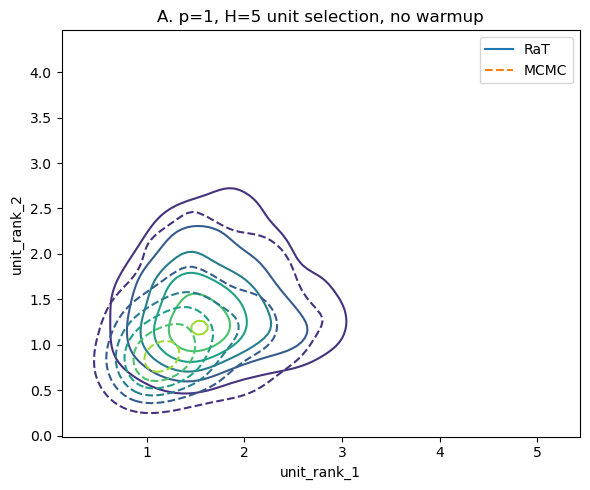

joint-active draws: RaT=4, MCMC=4900
joint-active probability: RaT=0.0040, MCMC=1.0000
Joint density not plotted: insufficient joint-active posterior draws.
joint-active draws: RaT=1000, MCMC=4900
joint-active probability: RaT=1.0000, MCMC=1.0000
conditional joint SKL: 0.1701


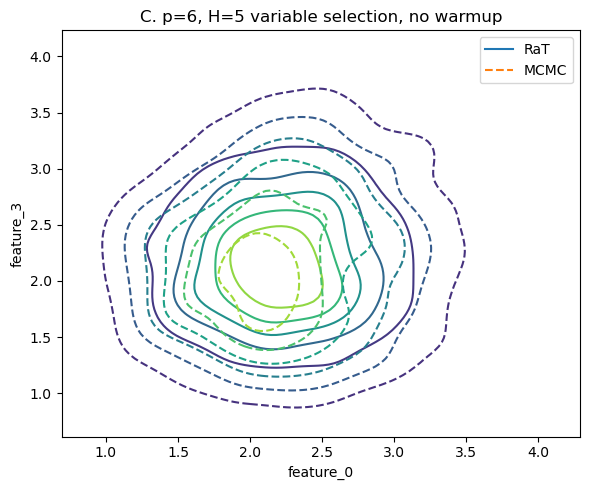

joint-active draws: RaT=1000, MCMC=4900
joint-active probability: RaT=1.0000, MCMC=1.0000
conditional joint SKL: 1.2922


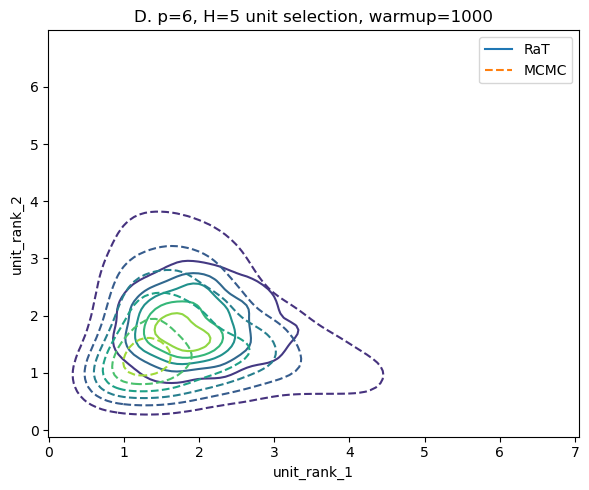

joint-active draws: RaT=1000, MCMC=4900
joint-active probability: RaT=1.0000, MCMC=1.0000
conditional joint SKL: 0.3950


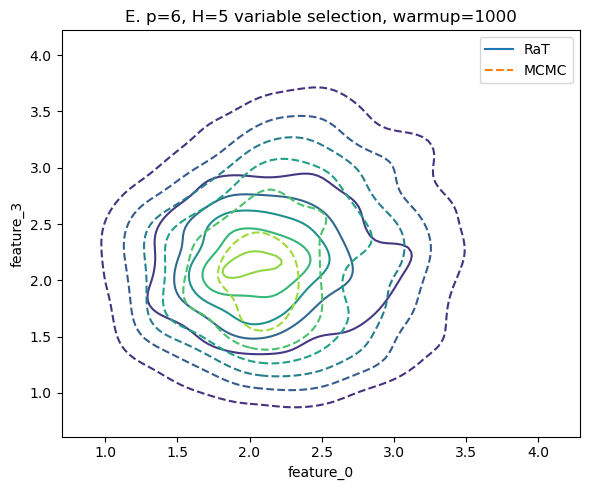

In [13]:

def plot_case_density(case, title):
    fig, ax = me.plot_true_active_joint_density(
        rat_decoder=case["out"]["model"].decoder,
        rat_xi=case["out"]["final"]["xi"],
        mcmc_decoder=case["mcmc_model"].decoder,
        mcmc_xi=case["mcmc_xi"],
        truth=case["info"],
        min_draws=50,
    )

    if fig is not None:
        ax.set_title(title)
        plt.show()


plot_case_density(
    case_A_nowarm,
    "A. p=1, H=5 unit selection, no warmup",
)

plot_case_density(
    case_B_nowarm,
    "B. p=6, H=5 unit selection, no warmup",
)

plot_case_density(
    case_C_nowarm,
    "C. p=6, H=5 variable selection, no warmup",
)

plot_case_density(
    case_D_warm_unit,
    "D. p=6, H=5 unit selection, warmup=1000",
)

plot_case_density(
    case_E_warm_feature,
    "E. p=6, H=5 variable selection, warmup=1000",
)


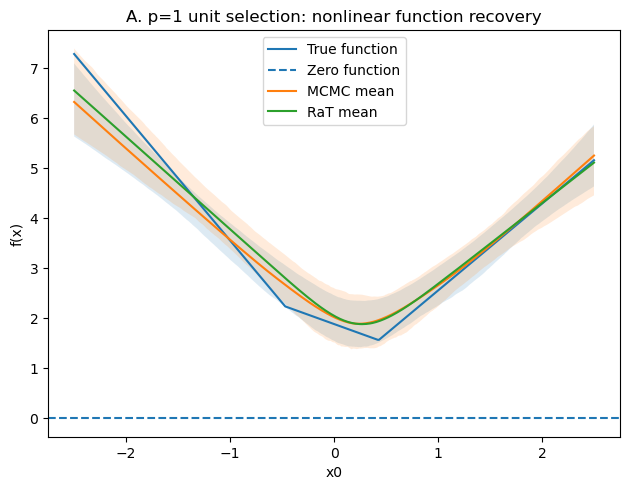

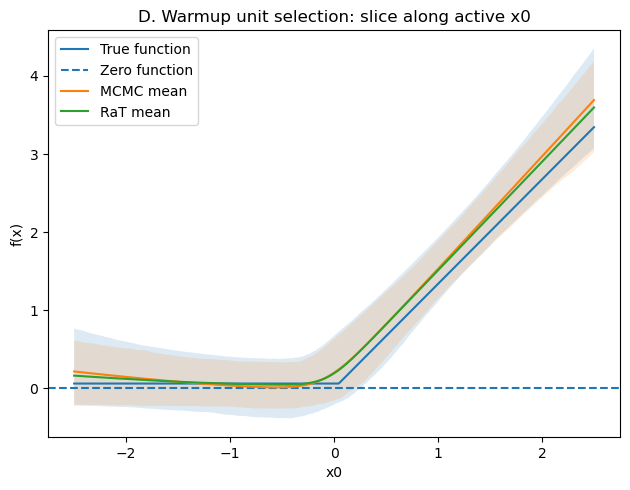

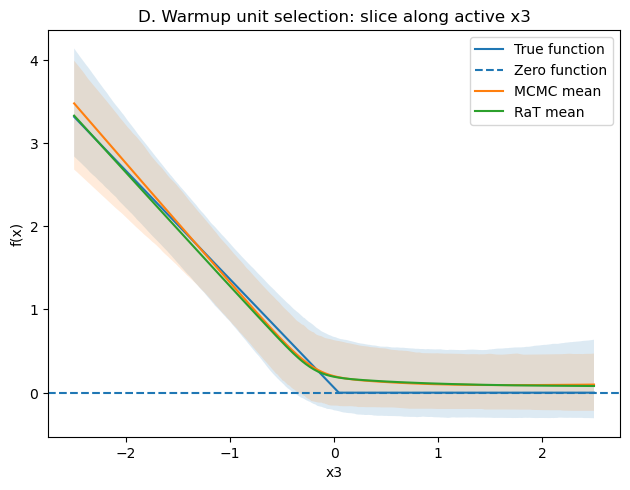

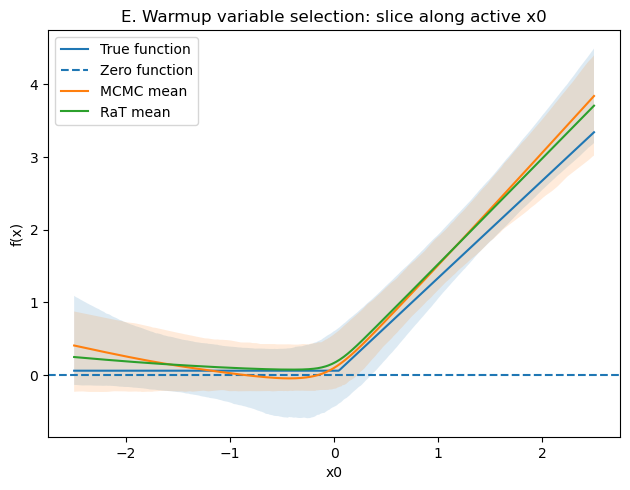

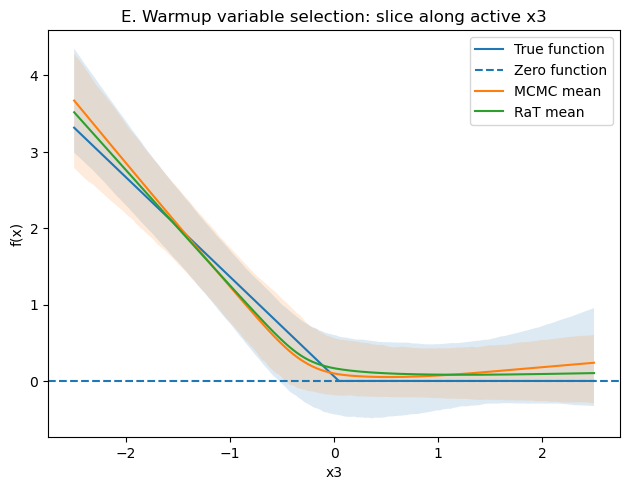

In [14]:

def plot_feature_slice(
    case,
    feature_idx,
    *,
    title,
    n_grid=400,
):
    X, y, feature_true, unit_true, signal, info = case["data"]

    x_low, x_high = info["x_range"]

    x_axis = torch.linspace(
        x_low,
        x_high,
        n_grid,
        device=device,
        dtype=X.dtype,
    )

    X_grid = torch.zeros(
        n_grid,
        X.shape[1],
        device=device,
        dtype=X.dtype,
    )

    X_grid[:, feature_idx] = x_axis

    signal_grid = sim.evaluate_grouped_teacher(
        X_grid,
        info,
    )

    mcmc_grid = me.predict_draws(
        case["mcmc_model"].decoder,
        X_grid,
        case["mcmc_xi"],
    )

    rat_grid = me.predict_draws(
        case["out"]["model"].decoder,
        X_grid,
        case["out"]["final"]["xi"],
    )

    fig, ax = me.plot_function_1d(
        x=x_axis.detach().cpu(),
        signal=signal_grid.detach().cpu(),
        mcmc_pred_draws=mcmc_grid,
        rat_pred_draws=rat_grid,
        method_label="RaT",
    )

    ax.set_xlabel(f"x{feature_idx}")
    ax.set_title(title)
    plt.show()


plot_feature_slice(
    case_A_nowarm,
    0,
    title="A. p=1 unit selection: nonlinear function recovery",
)

plot_feature_slice(
    case_D_warm_unit,
    0,
    title="D. Warmup unit selection: slice along active x0",
)

plot_feature_slice(
    case_D_warm_unit,
    3,
    title="D. Warmup unit selection: slice along active x3",
)

plot_feature_slice(
    case_E_warm_feature,
    0,
    title="E. Warmup variable selection: slice along active x0",
)

plot_feature_slice(
    case_E_warm_feature,
    3,
    title="E. Warmup variable selection: slice along active x3",
)


## Reporting checklist

For the presentation, the current executed results support the following narrative:

1. **Model:** one selectable group corresponds to one latent activation and one ReLU gate.
2. **Posterior:** attention-conditioned affine couplings remain exactly invertible while learning dependence between latent coordinates.
3. **One-dimensional unit sanity check:** \(p=1,H=5\) recovers both truth-active ranked units with PIP \(1\), \(R^2=0.9654\), and joint SKL \(0.2085\), although redundant ranks retain nonzero occupancy.
4. **Multivariable failure without warmup:** \(p=6,H=5\) unit selection collapses to ranked PIPs \((0.057,0.004,0,0,0)\) and \(R^2=-0.0034\); only four joint-active RaT draws exist, so no joint KDE is drawn.
5. **Variable-selection control:** on the same \(p=6,H=5\) teacher, no-warmup feature selection succeeds with truth-PIP RMSE \(0.0197\) and \(R^2=0.9693\).
6. **Warmup fix:** the \(p=6,H=5\) unit problem changes to ranked PIPs \((1,1,0.039,0,0)\), truth-PIP RMSE \(0.0174\), and \(R^2=0.9511\).
7. **Warmup generality:** feature selection remains accurate under the same control, with truth-PIP RMSE \(0.0167\) and \(R^2=0.9877\).
8. **Posterior-shape nuance:** warmup repairs support and function recovery but does not guarantee that every SKL metric decreases; the warmup unit joint SKL is \(1.2922\).
9. **Endpoint:** use the final epoch; validation-\(R^2\) checkpointing is not required for the posterior-recovery workflow.
10. **Metrics:** emphasize truth-PIP RMSE, active conditional SKL, and functional \(R^2\); interpret MCMC-PIP RMSE and zero JS as reference disagreement rather than truth-selection error.